In [1]:
import json
import struct
import numpy as np
import matplotlib.pyplot as plt
import photonforge as pf
import siepic_forge as siepic
import luxtelligence_lnoi400_forge as lxt
import tidy3d as td

td.config.logging_level = "ERROR"


# Set up technologies
siepic_tech = siepic.ebeam()
basic_tech = pf.basic_technology()
lxt_tech = lxt.lnoi400()
pf.config.default_technology = siepic_tech

# Initialize live viewer for real-time visualization
from photonforge.live_viewer import LiveViewer
viewer = LiveViewer()

# Define simulation parameters
wavelengths = np.linspace(1.53, 1.57, 101)
freqs = pf.C_0 / wavelengths

LiveViewer started at http://localhost:58141


In [2]:
dual_mode_spec = siepic_tech.ports["TE_1550_500"].copy()
dual_mode_spec.num_modes = 2  # Use both modes

siepic_tech.add_port("TE-TM_1550_500", dual_mode_spec)
siepic_tech.ports["TE-TM_1550_500"]

PortSpec(description="Strip TE 1550 nm, w=500 nm", width=2, limits=(-1, 1.22), num_modes=2, added_solver_modes=0, polarization="", target_neff=3.5, default_radius=0, path_profiles=[(0.5, 0, (1, 0))])

In [3]:
class ThermalModel(pf.Model):
    def __init__(self, n_complex, voltage=0, coefficient=3e-4):
        super().__init__(
            n_complex=n_complex,
            voltage=voltage,
            coefficient=coefficient,
        )
        self.n_complex = np.array(n_complex, ndmin=2)
        self.voltage = voltage
        self.coefficient = coefficient

    def __copy__(self):
        return ThermalModel(self.n_complex, self.voltage, self.coefficient)

    def __deepcopy__(self, memo=None):
        # n_complex is an array, so we want to make sure to create a deep copy of it.
        # Other values (voltage and coefficient) are immutable (floats), so we can use them directly.
        return ThermalModel(self.n_complex.copy(), self.voltage, self.coefficient)

    def __repr__(self):
        return f"ThermalModel({self.n_complex!r}, {self.voltage!r}, {self.coefficient!r})"

    def __str__(self):
        return f"ThermalModel at {self.voltage} V"

    @property
    def as_bytes(self):
        coeffs = struct.pack("<2d", self.voltage, self.coefficient)
        shape = struct.pack("<2l", *self.n_complex.shape)
        n_data = self.n_complex.astype(complex).tobytes()
        # Add version 0 as first byte
        return b"\x00" + coeffs + shape + n_data

    @classmethod
    def from_bytes(cls, byte_repr):
        version = byte_repr[0]
        if version != 0:
            raise RuntimeError(f"Incompatible version for ThermalModel: {version}")

        byte_repr = byte_repr[1:]
        fmt = "<2d2l"
        head_len = struct.calcsize(fmt)
        voltage, coefficient, rows, cols = struct.unpack(fmt, byte_repr[:head_len])

        byte_repr = byte_repr[head_len:]
        n_complex = np.frombuffer(byte_repr, dtype=complex).reshape((rows, cols))

        return cls(n_complex, voltage, coefficient)

    @pf.cache_s_matrix
    def start(self, component, frequencies, voltage=None, **kwargs):
        # Allow overriding voltage as an `s_matrix` kwarg too
        if voltage is None:
            voltage = self.voltage
        n_complex = self.n_complex + self.coefficient * voltage**2
        wg_model = pf.WaveguideModel(n_complex)
        return wg_model.start(component, frequencies, **kwargs)


pf.register_model_class(ThermalModel)

In [6]:
# Define a parametric 2x2 MMI splitter component
@pf.parametric_component
def mmi_2x2(
    *,
    l1=4.41,  # length of taper section at input
    l2=4.51,  # length of intermediate taper section
    l3=3.01,  # length of central multimode section
    w1=2.05,  # intermediate width near input/output
    w2=2.05,  # central section width
    w5=0.972,  # input taper narrow width
    w6=0.284,  # gap between input waveguides
    port_spec="TE_1550_500"  # port specification for waveguides
):
    """
    Creates a parametric 2x2 multimode interference (MMI) splitter component.

    Parameters:
        l1, l2, l3 (float): Section lengths.
        w1, w2, w5, w6 (float): Section widths.
        port_spec: Specification for the optical ports.

    Returns:
        PhotonForge Component: Configured MMI with geometry and simulation model.
    """
    # Resolve port specification if provided as string
    if isinstance(port_spec, str):
        port_spec = pf.config.default_technology.ports[port_spec]

    # Initialize an empty component named "MMI2x2"
    mmi = pf.Component("MMI2x2")

    # Extract default waveguide width from port specification
    wg_width, _ = port_spec.path_profile_for("Si")

    # Calculate widths based on given parameters
    w3 = 2 * w5 + w6
    w4 = wg_width

    # Define paths for input and output waveguides
    input_wg_up = pf.Path((0, (w5 + w6) / 2), w4).segment((l1, 0), w5, relative=True)
    input_wg_down = input_wg_up.copy().mirror()
    output_wg_up = input_wg_up.copy().mirror(
        axis_endpoint=(l1 + l2 + l3, 1), axis_origin=(l1 + l2 + l3, 0)
    )
    output_wg_down = output_wg_up.copy().mirror()

    # Define the central multimode section of MMI
    central_section = (
        pf.Path((l1, 0), w3)
        .segment((l2, 0), w1, relative=True)
        .segment((l3, 0), w2, relative=True)
        .segment((l3, 0), w2, relative=True)
        .segment((l2, 0), w3, relative=True)
    )

    # Add the defined geometries to the silicon ("Si") layer
    mmi.add(
        "Si", input_wg_up, input_wg_down, output_wg_up, output_wg_down, central_section
    )

    # Automatically detect and add ports
    mmi.add_port(mmi.detect_ports([port_spec]))
    assert len(mmi.ports) == 4, "Port detection failed: expected exactly 4 ports."

    # Include the Tidy3D simulation model with specified port symmetries
    mmi.add_model(
        pf.Tidy3DModel(
            port_symmetries=[
                ("P1", "P0", "P3", "P2"),  # reflection symmetry about x axis
                ("P2", "P3", "P0", "P1"),  # reflection symmetry about y axis
                ("P3", "P2", "P1", "P0"),  # inversion symmetry about the origin
            ],
        ),
        "Tidy3DModel",
    )

    return mmi

# Instantiate the MMI component with default dimensions
mmi = mmi_2x2()
# viewer(mmi)

c:\Users\irfan\AppData\Local\Programs\Python\Python313\Lib\site-packages\photonforge\parametric_utils.py:208: RuntimeWarning: Component function '__main__.mmi_2x2' previously registered will be overwritten.
  return _decorator(decorated_function)


In [7]:
@pf.parametric_component
def create_tunable_mzi(*, name="tunable_mzi", port_spec, coupling_distance=0.7, coupling_length=4.8, ps_length=5):
    if isinstance(port_spec, str):
        port_spec = pf.config.default_technology.ports[port_spec]

    # Bend and Straight waveguide to form the microring
    phase_shifter = pf.parametric.straight(name=f"{name}_ps", port_spec=port_spec, length=ps_length)
    straight = pf.parametric.straight(port_spec=port_spec, length=ps_length)
    bend = pf.parametric.bend(port_spec=port_spec, radius=5)
    coupler = pf.parametric.dual_ring_coupler(
        port_spec=port_spec, coupling_distance=coupling_distance, coupling_length=coupling_length, radius=5, 
        tidy3d_model_kwargs={
            # These symmetries are not correct for arbitrary ports.
            # They can be used in this case for the fundamental mode.
            "port_symmetries": [
                ("P1", "P0", "P3", "P2"),
                ("P2", "P3", "P0", "P1"),
                ("P3", "P2", "P1", "P0"),
            ],
        },
    )

    # Solve for the port mode of the waveguide and extract the complex refractive index
    alpha = 10
    kappa = (alpha * wavelengths * 1e-4 * np.log(10)) / (40 * np.pi)
    mode_solver = pf.port_modes(port=phase_shifter.ports["P0"], frequencies=freqs)
    n_complex = mode_solver.data.n_complex.values.T + 1j * kappa  # add propagation loss

    thermal_model = ThermalModel(n_complex=n_complex)
    phase_shifter.add_model(thermal_model, "Thermal")

    tunable_mzi = pf.Component("tunable_mzi")

    # form main microring structure
    cp1_ref = tunable_mzi.add_reference(coupler)
    cp2_ref = tunable_mzi.add_reference(coupler)
    ps1_ref = tunable_mzi.add_reference(phase_shifter)
    # ps2_ref = tunable_mzi.add_reference(phase_shifter)
    bend1_ref = tunable_mzi.add_reference(bend)
    bend2_ref = tunable_mzi.add_reference(bend) 
    bend3_ref = tunable_mzi.add_reference(bend)
    bend4_ref = tunable_mzi.add_reference(bend) 
    str1_ref = tunable_mzi.add_reference(straight)
    # str2_ref = tunable_mzi.add_reference(straight)

    #Coupler Kiri
    bend1_ref.connect("P1", cp1_ref["P3"])
    bend2_ref.connect("P0", cp1_ref["P2"])
    #Tengah
    ps1_ref.connect("P0", bend1_ref["P0"])
    str1_ref.connect("P0", bend2_ref["P1"])
    bend3_ref.connect("P1", ps1_ref["P1"])
    bend4_ref.connect("P0", str1_ref["P1"])
    #Coupler Kanan
    cp2_ref.connect("P1", bend3_ref["P0"])
    cp2_ref.connect("P0", bend4_ref["P1"])

    # st1_ref = tunable_mzi.add_reference(straight)
    # ps1_ref.connect("P0", cp1_ref["P1"])
    # # st1_ref.connect("P0", cp1_ref["P3"])
    # ps2_ref.connect("P0", cp1_ref["P3"])
    # cp2_ref.connect("P3", ps1_ref["P1"])

    # Define the heater and electrical path
    # terminal_width = 10

    # ## HORIZONTAL HEATERS
    # heater = (
    #     pf.Path((-radius-1.5, ps_length/2), ps_length)
    #     .segment((radius+1.5, ps_length/2), ps_length)
    # )

    # terminal_vp = (
    #     pf.Path((-radius-1.5 - terminal_width, ps_length/2), terminal_width)
    #     .segment((-radius-1.5, ps_length/2), terminal_width)
    # )

    # terminal_vn = (
    #     pf.Path((radius+1.5, ps_length/2), terminal_width)
    #     .segment((radius+1.5 + terminal_width, ps_length/2), terminal_width)
    # )

    # tunable_mzi.add((11,0), heater)
    # tunable_mzi.add((12,0), terminal_vp)
    # tunable_mzi.add((12,0), terminal_vn)
    # tunable_mzi.add_terminal(pf.Terminal((12,0), terminal_vp), "VP")
    # tunable_mzi.add_terminal(pf.Terminal((12,0), terminal_vn), "VN")

    ## VERTICAL HEATERS
    # heater_left = (
    #     pf.Path((-radius, 0), 3)
    #     .segment((-radius, ps_length), 3)
    # )

    # heater_right = (
    #     pf.Path((radius, 0), 3)
    #     .segment((radius, ps_length), 3)
    # )

    # terminal_vp = (
    #     pf.Path((0, ps_length+radius), 2*radius+terminal_width)
    #     .segment((0, ps_length+radius+terminal_width), 2*radius+terminal_width)
    # )

    # routing_top_left = (
    #     pf.Path((-radius, ps_length+radius), terminal_width)
    #     .segment((-radius, ps_length), 3)
    # )

    # routing_bott_left = (
    #     pf.Path((-radius, -radius), terminal_width)
    #     .segment((-radius, 0), 3)
    # )

    # terminal_vn = (
    #     pf.Path((0, -radius), 2*radius+terminal_width)
    #     .segment((0, -radius-terminal_width), 2*radius+terminal_width)
    # )

    # routing_top_right = (
    #     pf.Path((radius, ps_length+radius), terminal_width)
    #     .segment((radius, ps_length), 3)
    # )

    # routing_bott_right = (
    #     pf.Path((radius, -radius), terminal_width)
    #     .segment((radius, 0), 3)
    # )

    # tunable_mzi.add((11,0), heater_left)
    # tunable_mzi.add((11,0), heater_right)
    # tunable_mzi.add((12,0), terminal_vp)
    # tunable_mzi.add((12,0), terminal_vn)
    # tunable_mzi.add((12,0), routing_top_left)
    # tunable_mzi.add((12,0), routing_bott_left)
    # tunable_mzi.add((12,0), routing_top_right)
    # tunable_mzi.add((12,0), routing_bott_right)
    # tunable_mzi.add_terminal(pf.Terminal((12,0), terminal_vp), "VP")
    # tunable_mzi.add_terminal(pf.Terminal((12,0), terminal_vn), "VN")


    ## COMPONENT MODELS
    tunable_mzi.add_port(tunable_mzi.detect_ports([port_spec]))
    tunable_mzi.add_model(pf.CircuitModel(), "CircuitModel")

    port_symmetries = [
        ("P2", "P3", "P0", "P1"),
        ("P1", "P0", "P3", "P2"),
    ]

    field_monitor = td.FieldMonitor(
        center=(0, 0, 0.11), size=(td.inf, td.inf, 0), freqs=[freqs.mean()], name="field"
    )

    tunable_mzi.add_model(pf.Tidy3DModel(port_symmetries=port_symmetries, monitors=[field_monitor]), "Tidy3DModel")

    return tunable_mzi

tunable_mzi = create_tunable_mzi(port_spec="Rib_TE_1550_500", ps_length=100)
# viewer(tunable_mzi)

Progress: 100% 


c:\Users\irfan\AppData\Local\Programs\Python\Python313\Lib\site-packages\photonforge\parametric_utils.py:208: RuntimeWarning: Component function '__main__.create_tunable_mzi' previously registered will be overwritten.
  return _decorator(decorated_function)


In [ ]:
@pf.parametric_component
def create_mzm(*, name, port_spec="TE_1550_500", coupling_distance=0.6, coupling_length=5.35, ps_length=100):

    # Bend and Straight waveguide to form the microring
    phase_shifter = pf.parametric.straight(name=f"ps", port_spec=port_spec, length=ps_length)
    straight = pf.parametric.straight(port_spec=port_spec, length=ps_length)
    bend = pf.parametric.bend(port_spec=port_spec, radius=5)
    coupler = pf.parametric.dual_ring_coupler(
        port_spec=port_spec, coupling_distance=coupling_distance, coupling_length=coupling_length, radius=5, 
        tidy3d_model_kwargs={
            # These symmetries are not correct for arbitrary ports.
            # They can be used in this case for the fundamental mode.
            "port_symmetries": [
                ("P1", "P0", "P3", "P2"),
                ("P2", "P3", "P0", "P1"),
                ("P3", "P2", "P1", "P0"),
            ],
        },
    )

    # Solve for the port mode of the waveguide and extract the complex refractive index
    alpha = 10
    kappa = (alpha * wavelengths * 1e-4 * np.log(10)) / (40 * np.pi)
    mode_solver = pf.port_modes(port=phase_shifter.ports["P0"], frequencies=freqs)
    n_complex = mode_solver.data.n_complex.values.T + 1j * kappa  # add propagation loss

    thermal_model = ThermalModel(n_complex=n_complex)
    phase_shifter.add_model(thermal_model, "Thermal")

    mzm = pf.Component(name)

    # form main microring structure
    cp1_ref = mzm.add_reference(coupler)
    cp2_ref = mzm.add_reference(coupler)
    ps1_ref = mzm.add_reference(phase_shifter)
    bend1_ref = mzm.add_reference(bend)
    bend2_ref = mzm.add_reference(bend) 
    bend3_ref = mzm.add_reference(bend)
    bend4_ref = mzm.add_reference(bend) 
    str1_ref = mzm.add_reference(straight)

    #Coupler Kiri
    bend1_ref.connect("P1", cp1_ref["P3"])
    bend2_ref.connect("P0", cp1_ref["P2"])
    #Tengah
    # trans1_ref.connect("P0", bend1_ref["P0"])
    ps1_ref.connect("P0", bend1_ref["P0"])
    str1_ref.connect("P0", bend2_ref["P1"])

    # trans2_ref.connect("P1", ps1_ref["P1"])
    bend3_ref.connect("P1", ps1_ref["P1"])
    bend4_ref.connect("P0", str1_ref["P1"])
    #Coupler Kanan
    cp2_ref.connect("P1", bend3_ref["P0"])
    cp2_ref.connect("P0", bend4_ref["P1"])

    # Define the heater and electrical path
    terminal_width = 10
    heater_width = 2

    heater = (
        pf.Path((ps1_ref.x_min, ps1_ref.y_mid), heater_width)
        .segment((ps1_ref.x_max, ps1_ref.y_mid), heater_width)
    )

    route_vp = (
        pf.Path((cp1_ref.x_mid-terminal_width/2, ps1_ref.y_mid), terminal_width)
        .segment((cp1_ref.x_mid+terminal_width/2, ps1_ref.y_mid), terminal_width)
        .segment((ps1_ref.x_min, ps1_ref.y_mid), heater_width)
    )

    route_vn = (
        pf.Path((ps1_ref.x_max, ps1_ref.y_mid), heater_width)
        .segment((cp2_ref.x_mid-terminal_width/2, ps1_ref.y_mid), terminal_width)
        .segment((cp2_ref.x_mid+terminal_width/2, ps1_ref.y_mid), terminal_width)
    )

    mzm.add((11,0), heater)
    mzm.add((12,0), route_vp)
    mzm.add((12,0), route_vn)
    mzm.add_terminal(pf.Terminal((12,0), pf.Rectangle(size=(terminal_width, terminal_width), center=(cp1_ref.x_mid, ps1_ref.y_mid))), "VP")
    mzm.add_terminal(pf.Terminal((12,0), pf.Rectangle(size=(terminal_width, terminal_width), center=(cp2_ref.x_mid, ps1_ref.y_mid))), "VN")

    ## COMPONENT MODELS
    mzm.add_port(mzm.detect_ports([port_spec]))
    mzm.add_model(pf.CircuitModel(), "CircuitModel")

    port_symmetries = [
        ("P1", "P0", "P3", "P2"),
        ("P2", "P3", "P0", "P1"),
        ("P3", "P2", "P1", "P0"),
    ]

    field_monitor = td.FieldMonitor(
        center=(0, 0, 0.11), size=(td.inf, td.inf, 0), freqs=[freqs.mean()], name="field"
    )

    # mzm.add_model(pf.Tidy3DModel(port_symmetries=port_symmetries, monitors=[field_monitor]), "Tidy3DModel")

    return mzm

mzm = create_mzm(name="mzm", port_spec="TE-TM_1550_500", ps_length=100, coupling_length=4.3)
viewer(mzm)

In [29]:
@pf.parametric_component
def create_mzm_mmi(*, name, port_spec="TE_1550_500", ps_length=100):

    # Bend and Straight waveguide to form the microring
    phase_shifter = pf.parametric.straight(name=f"ps", port_spec=port_spec, length=ps_length)
    straight = pf.parametric.straight(port_spec=port_spec, length=ps_length)
    s_bend_up = pf.parametric.s_bend(port_spec=port_spec, length=10, offset=5)
    s_bend_down = pf.parametric.s_bend(port_spec=port_spec, length=10, offset=-5)
    mmi = mmi_2x2(port_spec=port_spec)

    # Solve for the port mode of the waveguide and extract the complex refractive index
    alpha = 10
    kappa = (alpha * wavelengths * 1e-4 * np.log(10)) / (40 * np.pi)
    mode_solver = pf.port_modes(port=phase_shifter.ports["P0"], frequencies=freqs)
    n_complex = mode_solver.data.n_complex.values.T + 1j * kappa  # add propagation loss

    thermal_model = ThermalModel(n_complex=n_complex)
    phase_shifter.add_model(thermal_model, "Thermal")

    mzm = pf.Component(name)

    # form main microring structure
    mmi1_ref = mzm.add_reference(mmi)
    mmi2_ref = mzm.add_reference(mmi)
    sb1_ref = mzm.add_reference(s_bend_up)
    sb2_ref = mzm.add_reference(s_bend_down)
    sb3_ref = mzm.add_reference(s_bend_down)
    sb4_ref = mzm.add_reference(s_bend_up)
    sb5_ref = mzm.add_reference(s_bend_up)
    sb6_ref = mzm.add_reference(s_bend_down)
    sb7_ref = mzm.add_reference(s_bend_down)
    sb8_ref = mzm.add_reference(s_bend_up)
    ps1_ref = mzm.add_reference(phase_shifter)
    ps2_ref = mzm.add_reference(phase_shifter)
    # str1_ref = mzm.add_reference(straight)

    #MMI Kiri
    sb1_ref.connect("P1", mmi1_ref["P0"])
    sb2_ref.connect("P1", mmi1_ref["P1"])
    sb3_ref.connect("P0", mmi1_ref["P2"])
    sb4_ref.connect("P0", mmi1_ref["P3"])
    #Tengah
    # str1_ref.connect("P0", sb3_ref["P1"])
    ps2_ref.connect("P0", sb3_ref["P1"])
    ps1_ref.connect("P0", sb4_ref["P1"])
    #MMI Kanan
    sb5_ref.connect("P0", ps2_ref["P1"])
    sb6_ref.connect("P0", ps1_ref["P1"])
    mmi2_ref.connect("P0", sb5_ref["P1"])
    mmi2_ref.connect("P1", sb6_ref["P1"])
    sb7_ref.connect("P0", mmi2_ref["P2"])
    sb8_ref.connect("P0", mmi2_ref["P3"])

    # Define the heater and electrical path
    terminal_width = 10
    heater_width = 2

    heater_top = (
        pf.Path((ps1_ref.x_min, ps1_ref.y_mid), heater_width)
        .segment((ps1_ref.x_max, ps1_ref.y_mid), heater_width)
    )
    heater_bott = (
        pf.Path((ps2_ref.x_min, ps2_ref.y_mid), heater_width)
        .segment((ps2_ref.x_max, ps2_ref.y_mid), heater_width)
    )

    route_vp = (
        pf.Path((mmi1_ref.x_mid-terminal_width/2, ps1_ref.y_mid), terminal_width)
        .segment((mmi1_ref.x_mid+terminal_width/2, ps1_ref.y_mid), terminal_width)
        .segment((ps1_ref.x_min, ps1_ref.y_mid), heater_width)
    )

    route_vn = (
        pf.Path((ps1_ref.x_max, ps1_ref.y_mid), heater_width)
        .segment((mmi2_ref.x_mid-terminal_width/2, ps1_ref.y_mid), terminal_width)
        .segment((mmi2_ref.x_mid+terminal_width/2, ps1_ref.y_mid), terminal_width)
    )

    mzm.add((11,0), heater_top)
    mzm.add((11,0), heater_bott)
    mzm.add((12,0), route_vp)
    mzm.add((12,0), route_vn)
    mzm.add_terminal(pf.Terminal((12,0), pf.Rectangle(size=(terminal_width, terminal_width), center=(mmi1_ref.x_mid, ps1_ref.y_mid))), "VP")
    mzm.add_terminal(pf.Terminal((12,0), pf.Rectangle(size=(terminal_width, terminal_width), center=(mmi2_ref.x_mid, ps1_ref.y_mid))), "VN")

    ## COMPONENT MODELS
    mzm.add_port(mzm.detect_ports([port_spec]))
    mzm.add_model(pf.CircuitModel(), "CircuitModel")

    port_symmetries = [
        ("P1", "P0", "P3", "P2"),
        ("P2", "P3", "P0", "P1"),
        ("P3", "P2", "P1", "P0"),
    ]

    field_monitor = td.FieldMonitor(
        center=(0, 0, 0.11), size=(td.inf, td.inf, 0), freqs=[freqs.mean()], name="field"
    )

    # mzm.add_model(pf.Tidy3DModel(port_symmetries=port_symmetries, monitors=[field_monitor]), "Tidy3DModel")

    return mzm

mzm = create_mzm_mmi(name="mzm", port_spec="TE_1550_500", ps_length=100)
viewer(mzm)

Progress: 100% 


c:\Users\irfan\AppData\Local\Programs\Python\Python313\Lib\site-packages\photonforge\parametric_utils.py:208: RuntimeWarning: Component function '__main__.create_mzm_mmi' previously registered will be overwritten.
  return _decorator(decorated_function)


In [10]:
component = mzm
# component.activate_model('Tidy3DModel')
component.activate_model('CircuitModel')

CircuitModel(mesh_refinement=None, verbose=True)

In [9]:
# simulations = component.active_model.get_simulations(component, freqs)

# # simulations.keys()
# td.web.Batch(simulations=simulations).estimate_cost()

c:\Users\irfan\AppData\Local\Programs\Python\Python313\Lib\site-packages\photonforge\circuit_base.py:211: RuntimeWarning: Terminal 'VN' at (155.79, 5.628) from component 'mzm' does not match any reference terminals and will be ignored.
  netlist = component.get_netlist()
c:\Users\irfan\AppData\Local\Programs\Python\Python313\Lib\site-packages\photonforge\circuit_base.py:211: RuntimeWarning: Terminal 'VP' at (11.93, 5.628) from component 'mzm' does not match any reference terminals and will be ignored.
  netlist = component.get_netlist()


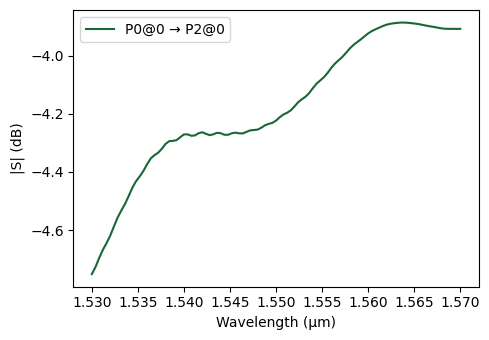

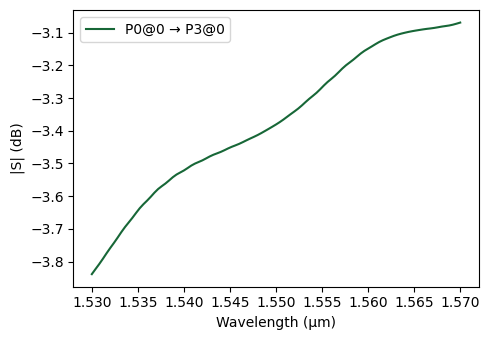

In [47]:
updates = {("ps", 0): {"model_updates": {"voltage": 4.33}, "inputs": ["P0"]}, 
            ("ps", 1): {"model_updates": {"voltage": 2.50}, "inputs": ["P0"]}}
s = component.s_matrix(
    pf.C_0 / wavelengths, model_kwargs={"updates": updates}, show_progress=False
)
fig, ax = pf.plot_s_matrix(s, input_ports=["P0"], output_ports=["P2"], y="dB")
fig, ax = pf.plot_s_matrix(s, input_ports=["P0"], output_ports=["P3"], y="dB")

c:\Users\irfan\AppData\Local\Programs\Python\Python313\Lib\site-packages\photonforge\circuit_base.py:211: RuntimeWarning: Terminal 'VN' at (155.79, 5.628) from component 'mzm' does not match any reference terminals and will be ignored.
  netlist = component.get_netlist()
c:\Users\irfan\AppData\Local\Programs\Python\Python313\Lib\site-packages\photonforge\circuit_base.py:211: RuntimeWarning: Terminal 'VP' at (11.93, 5.628) from component 'mzm' does not match any reference terminals and will be ignored.
  netlist = component.get_netlist()


Loading cached simulation from C:\Users\irfan\.tidy3d\pf_cache\4LF\fdtd_info-MJFRMNKW46CDU5PJDPQLAFYL5F5RGRUTKACPIS3M4ZOT2REKCBCA.json.


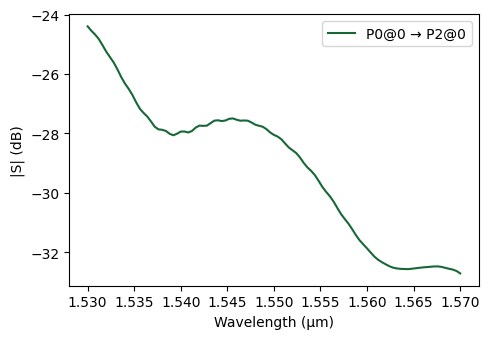

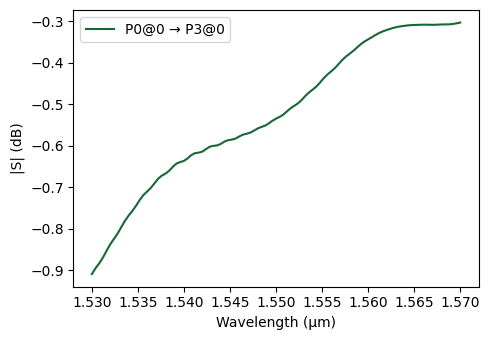

In [11]:
s_matrix = component.s_matrix(freqs, model_kwargs={"inputs": ["P0"]})
fig, ax = pf.plot_s_matrix(s_matrix, input_ports=["P0"], output_ports=["P2"], y="dB")
fig, ax = pf.plot_s_matrix(s_matrix, input_ports=["P0"], output_ports=["P3"], y="dB")

In [ ]:
# sim_data = component.active_model.batch_data_for(component)
# _ = sim_data["P0@0"].plot_field("field", "E", val="abs^2", robust=False)

Progress: 100% 


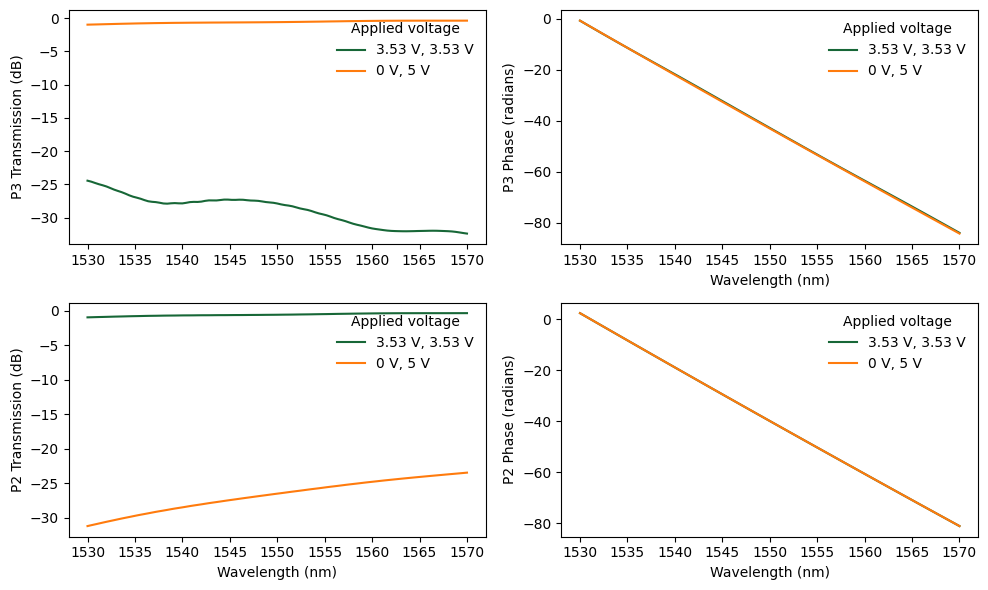

In [49]:
# the list of voltages
top_voltages = [3.53, 0]
bott_voltages = [3.53, 5]


# make one figure/axes
fig, axs = plt.subplots(nrows=2, ncols=2, sharex=False, sharey=False, figsize=(10, 6))

component = create_mzm_mmi(name="mzm", port_spec="TE_1550_500", ps_length=100)

for i in range(2):
    updates = {("ps", 0): {"model_updates": {"voltage": top_voltages[i]}},
               ("ps", 1): {"model_updates": {"voltage": bott_voltages[i]}}}
    s_matrix = component.s_matrix(freqs, model_kwargs={"updates": updates, "inputs": ["P0@0"]})
    s20 = s_matrix[("P0@0", "P2@0")]
    s21 = s_matrix[("P0@0", "P3@0")]
    axs[0, 0].plot(
        wavelengths * 1e3,
        # np.cos(np.angle(s20)),
        20 * np.log10(np.abs(s20)),
        label=f"{top_voltages[i]} V, {bott_voltages[i]} V",
        linewidth=1.5,
    )
    axs[1, 0].plot(
        wavelengths * 1e3,
        # np.cos(np.angle(s21)),
        20 * np.log10(np.abs(s21)),
        label=f"{top_voltages[i]} V, {bott_voltages[i]} V",
        linewidth=1.5,
    )
    axs[0, 1].plot(
        wavelengths * 1e3,
        np.unwrap(np.angle(s20)),
        label=f"{top_voltages[i]} V, {bott_voltages[i]} V",
        linewidth=1.5,
    )
    axs[1, 1].plot(
        wavelengths * 1e3,
        np.unwrap(np.angle(s21)),
        label=f"{top_voltages[i]} V, {bott_voltages[i]} V",
        linewidth=1.5,
    )


# labels & legend
# axs[0, 0].set_xlabel("Wavelength (nm)")
axs[0, 0].set_ylabel("P3 Transmission (dB)")
axs[0, 0].legend(title="Applied voltage", loc="upper right", frameon=False)
axs[1, 0].set_xlabel("Wavelength (nm)")
axs[1, 0].set_ylabel("P2 Transmission (dB)")
axs[1, 0].legend(title="Applied voltage", loc="upper right", frameon=False)
axs[0, 1].set_xlabel("Wavelength (nm)")
axs[0, 1].set_ylabel("P3 Phase (radians)")
axs[0, 1].legend(title="Applied voltage", loc="upper right", frameon=False)
axs[1, 1].set_xlabel("Wavelength (nm)")
axs[1, 1].set_ylabel("P2 Phase (radians)")
axs[1, 1].legend(title="Applied voltage", loc="upper right", frameon=False)

plt.tight_layout()
plt.show()

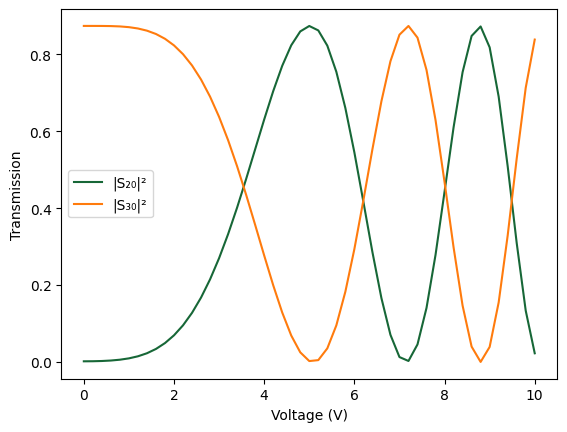

In [40]:
voltages = np.linspace(0, 10, 51)
transmission = np.zeros((voltages.size, 2))
k = len(wavelengths) // 2  # Look at central wavelength

for i, v in enumerate(voltages):
    updates = {("ps", 0): {"model_updates": {"voltage": 0}, "inputs": ["P0"]}, 
               ("ps", 1): {"model_updates": {"voltage": v}, "inputs": ["P0"]}}
    s = component.s_matrix(
        pf.C_0 / wavelengths, model_kwargs={"updates": updates}, show_progress=False
    )
    transmission[i, 0] = np.abs(s[("P0@0", "P2@0")][k]) ** 2
    transmission[i, 1] = np.abs(s[("P0@0", "P3@0")][k]) ** 2

# Plot results
plt.plot(voltages, transmission)
plt.xlabel("Voltage (V)")
plt.ylabel("Transmission")
plt.legend(["|S₂₀|²", "|S₃₀|²"])
plt.show()

In [ ]:
component.get_netlist()